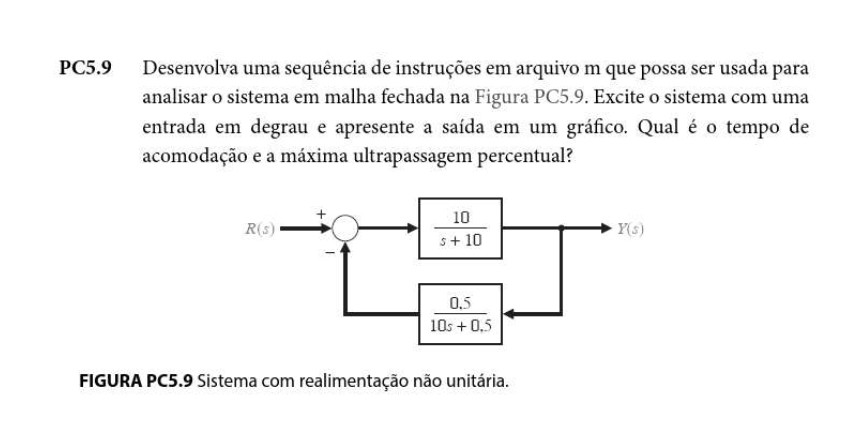

PROBLEMA PC5.9 - ANÁLISE DE SISTEMA COM REALIMENTAÇÃO NÃO-UNITÁRIA

(1) COMPONENTES DO SISTEMA:
-------------------------------------------------------------------------------------

Caminho direto: G(s) = 10/(s+10) =
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    10
  ------
  s + 10

Caminho de realimentação: H(s) = 0.5/(10s+0.5) =
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     0.5
  ----------
  10 s + 0.5

H(s) simplificado: H(s) = 0.05/(s+0.05) =
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.05
  --------
  s + 0.05

FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:
L(s) = G(s)*H(s) =
<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

           5
  --------------------
  10 s^2 + 100.5 s + 5

Numerador de L(s): [5.]
Denominador de L(s): [ 10.  100.5   5. ]

FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:
T(s) = G(s)/(1 + G(s)*H(s)) = Y(s)/R(s) =
<TransferFunction>: sys[4]
Inputs (1): ['u[

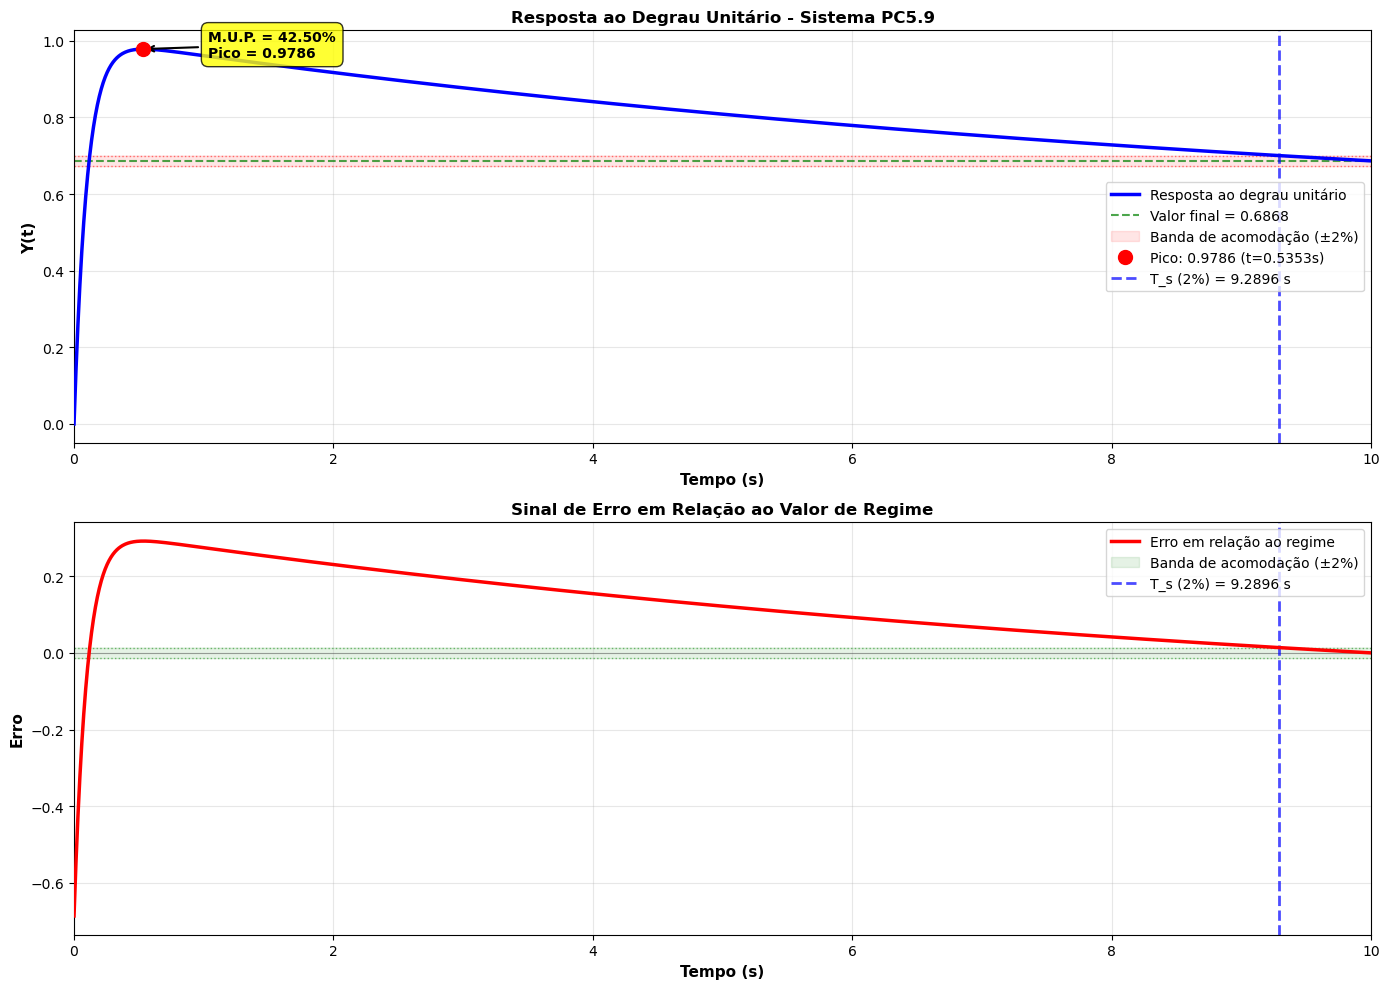


RESUMO DOS RESULTADOS:

✓ Máxima Ultrapassagem Percentual (M.U.P.): 42.50%
✓ Tempo de Acomodação (Critério 2%):    9.289645 s
✓ Tempo de Acomodação (Critério 5%):    8.319160 s
✓ Tempo de Pico:                         0.535268 s
✓ Sistema é ESTÁVEL

✓ Gráfico salvo como 'system_pc59_response.png'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

print("=" * 85)
print("PROBLEMA PC5.9 - ANÁLISE DE SISTEMA COM REALIMENTAÇÃO NÃO-UNITÁRIA")
print("=" * 85)

# Define the system components from the block diagram
# Forward path: G(s) = 10/(s+10)
# Feedback path: H(s) = 0.5/(10s+0.5)
# Negative feedback

print("\n(1) COMPONENTES DO SISTEMA:")
print("-" * 85)

# Forward path transfer function: G(s) = 10/(s+10)
num_G = [10]           # numerador: 10
den_G = [1, 10]        # denominador: s + 10

G = ct.TransferFunction(num_G, den_G)
print("\nCaminho direto: G(s) = 10/(s+10) =")
print(G)

# Feedback path transfer function: H(s) = 0.5/(10s+0.5)
# Simplifying: H(s) = 0.5/(10(s+0.05)) = 0.05/(s+0.05)
num_H = [0.5]          # numerador: 0.5
den_H = [10, 0.5]      # denominador: 10s + 0.5

H = ct.TransferFunction(num_H, den_H)
print("\nCaminho de realimentação: H(s) = 0.5/(10s+0.5) =")
print(H)

# Simplify H(s)
H_simplified = ct.TransferFunction([0.05], [1, 0.05])
print("\nH(s) simplificado: H(s) = 0.05/(s+0.05) =")
print(H_simplified)

# Calculate open-loop transfer function: L(s) = G(s)*H(s)
L = G * H
print("\n" + "=" * 85)
print("FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:")
print("=" * 85)
print("L(s) = G(s)*H(s) =")
print(L)

# Extract numerator and denominator of L(s)
num_L, den_L = ct.tfdata(L)
num_L = num_L[0][0]
den_L = np.asarray(den_L[0]).flatten()

print("\nNumerador de L(s):", num_L)
print("Denominador de L(s):", den_L)

# Calculate closed-loop transfer function: T(s) = G(s)/(1 + G(s)*H(s))
T = ct.feedback(G, H)

print("\n" + "=" * 85)
print("FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:")
print("=" * 85)
print("T(s) = G(s)/(1 + G(s)*H(s)) = Y(s)/R(s) =")
print(T)

# Extract numerator and denominator of T(s)
num_T, den_T = ct.tfdata(T)
num_T = num_T[0][0]
den_T_flat = np.asarray(den_T[0]).flatten()

print("\nNumerador de T(s):", num_T)
print("Denominador de T(s):", den_T_flat)

# Calculate poles and check system stability
print("\n" + "=" * 85)
print("ANÁLISE DO SISTEMA:")
print("=" * 85)

poles = np.roots(den_T_flat)
print("\nPólos do sistema em malha fechada:")
for i, pole in enumerate(poles):
    if np.isreal(pole):
        print(f"  Pólo {i+1}: {pole.real:.6f}")
    else:
        print(f"  Pólo {i+1}: {pole.real:.6f} ± j{abs(pole.imag):.6f}")

# Check stability (all poles must have negative real parts)
is_stable = all(p.real < 0 for p in poles)
print(f"\nEstabilidade: {'ESTÁVEL' if is_stable else 'INSTÁVEL'}")

# Simulate step response
print("\n" + "=" * 85)
print("RESPOSTA AO DEGRAU UNITÁRIO:")
print("=" * 85)

t = np.linspace(0, 10, 2000)
t_out, y = ct.step_response(T, T=t)

# Find the peak (overshoot)
peak_idx = np.argmax(y)
peak_value = y[peak_idx]
peak_time = t_out[peak_idx]

# Final value (steady-state)
final_value = y[-1]

# Calculate percent overshoot
percent_overshoot = ((peak_value - final_value) / final_value) * 100

# Find settling time (2% criterion)
settling_time = None
tolerance = 0.02  # 2%
for i in range(len(y) - 1, 0, -1):
    if abs(y[i] - final_value) > tolerance * abs(final_value):
        settling_time = t_out[i]
        break

# Find settling time (5% criterion) as well
settling_time_5pct = None
tolerance_5 = 0.05  # 5%
for i in range(len(y) - 1, 0, -1):
    if abs(y[i] - final_value) > tolerance_5 * abs(final_value):
        settling_time_5pct = t_out[i]
        break

print(f"\nRESULTADOS:")
print(f"  Valor final (regime estacionário): {final_value:.6f}")
print(f"  Valor de pico: {peak_value:.6f}")
print(f"  Tempo de pico: {peak_time:.6f} s")
print(f"  Percentual de ultrapassagem (M.U.P.): {percent_overshoot:.2f}%")
if settling_time:
    print(f"  Tempo de acomodação (2%): {settling_time:.6f} s")
if settling_time_5pct:
    print(f"  Tempo de acomodação (5%): {settling_time_5pct:.6f} s")

# Try to identify second-order characteristics for comparison
print("\n" + "=" * 85)
print("CARACTERÍSTICAS DO SISTEMA:")
print("=" * 85)

# If system is second-order, extract ωn and ζ
if len(poles) == 2:
    complex_poles = poles[np.iscomplex(poles)]
    if len(complex_poles) > 0:
        dominant_pole = complex_poles[0]
        omega_n = abs(dominant_pole)
        zeta = -dominant_pole.real / omega_n
        print(f"\nSistema de 2ª ordem:")
        print(f"  ωn (frequência natural) = {omega_n:.6f} rad/s")
        print(f"  ζ (amortecimento relativo) = {zeta:.6f}")
    else:
        print(f"\nSistema é de 2ª ordem com dois pólos reais (superamortecido)")
else:
    print(f"\nSistema é de ordem {len(poles)} (não é de 2ª ordem)")

# Create plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Step response
ax1 = axes[0]
ax1.plot(t_out, y, 'b-', linewidth=2.5, label='Resposta ao degrau unitário', zorder=3)
ax1.axhline(y=final_value, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Valor final = {final_value:.4f}')

# Settling band (2%)
ax1.axhline(y=final_value * 1.02, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax1.axhline(y=final_value * 0.98, color='r', linestyle=':', linewidth=1, alpha=0.5)
ax1.fill_between(t_out, final_value * 0.98, final_value * 1.02, alpha=0.1, color='red', label='Banda de acomodação (±2%)')

# Mark peak
ax1.plot(peak_time, peak_value, 'ro', markersize=10, zorder=4, label=f'Pico: {peak_value:.4f} (t={peak_time:.4f}s)')
ax1.annotate(f'M.U.P. = {percent_overshoot:.2f}%\nPico = {peak_value:.4f}', 
            xy=(peak_time, peak_value), 
            xytext=(peak_time + 0.5, peak_value - 0.02),
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
            arrowprops=dict(arrowstyle='->', lw=1.5))

# Mark settling time
if settling_time:
    ax1.axvline(x=settling_time, color='b', linestyle='--', linewidth=2, alpha=0.7, label=f'T_s (2%) = {settling_time:.4f} s')

ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Y(t)', fontsize=11, fontweight='bold')
ax1.set_title('Resposta ao Degrau Unitário - Sistema PC5.9', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='right')
ax1.set_xlim(0, 10)

# Plot 2: Error from final value
ax2 = axes[1]
error = y - final_value
ax2.plot(t_out, error, 'r-', linewidth=2.5, label='Erro em relação ao regime', zorder=3)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.3)
ax2.axhline(y=final_value * 0.02, color='g', linestyle=':', linewidth=1, alpha=0.5)
ax2.axhline(y=-final_value * 0.02, color='g', linestyle=':', linewidth=1, alpha=0.5)
ax2.fill_between(t_out, -final_value * 0.02, final_value * 0.02, alpha=0.1, color='green', label='Banda de acomodação (±2%)')

# Mark settling time
if settling_time:
    ax2.axvline(x=settling_time, color='b', linestyle='--', linewidth=2, alpha=0.7, label=f'T_s (2%) = {settling_time:.4f} s')

ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Erro', fontsize=11, fontweight='bold')
ax2.set_title('Sinal de Erro em Relação ao Valor de Regime', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim(0, 10)

plt.tight_layout()
plt.savefig('system_pc59_response.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "=" * 85)
print("RESUMO DOS RESULTADOS:")
print("=" * 85)
print(f"\n✓ Máxima Ultrapassagem Percentual (M.U.P.): {percent_overshoot:.2f}%")
if settling_time:
    print(f"✓ Tempo de Acomodação (Critério 2%):    {settling_time:.6f} s")
if settling_time_5pct:
    print(f"✓ Tempo de Acomodação (Critério 5%):    {settling_time_5pct:.6f} s")
print(f"✓ Tempo de Pico:                         {peak_time:.6f} s")
print(f"✓ Sistema é {'ESTÁVEL' if is_stable else 'INSTÁVEL'}")
print("\n✓ Gráfico salvo como 'system_pc59_response.png'")
print("=" * 85)